# **Imports**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

from datasets import load_dataset
from transformers import BertTokenizerFast
!pip install torchmetrics
from torchmetrics import Accuracy

In [4]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# **1. Dataset Preparation**

## **1.1 Load the Dataset**

In [ ]:
dataset = load_dataset("cardiffnlp/tweet_eval", "sentiment")
dataset

README.md:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

In [6]:
print("Available splits:", list(dataset.keys()))
print(f"Train examples      : {len(dataset['train'])}")
print(f"Validation examples: {len(dataset['validation'])}")
print(f"Test examples      : {len(dataset['test'])}")
print("Column names:", dataset["train"].column_names)
print("Text column  : text")
print("Label column : label")

Available splits: ['train', 'test', 'validation']
Train examples      : 45615
Validation examples: 2000
Test examples      : 12284
Column names: ['text', 'label']
Text column  : text
Label column : label


## **1.2 Inspect the Dataset**

In [9]:
label2sentiment = {0: "Negative", 1: "Neutral", 2: "Positive"}

print("Five examples from the training set:\n")
for i in range(5):
    text  = dataset["train"][i]["text"]
    label = dataset["train"][i]["label"]
    print(f"Example {i+1}")
    print(f"  Text      : {text}")
    print(f"  Label     : {label}")
    print(f"  Sentiment : {label2sentiment[label]}")
    print("-" * 60)

Five examples from the training set:

Example 1
  Text      : "QT @user In the original draft of the 7th book, Remus Lupin survived the Battle of Hogwarts. #HappyBirthdayRemusLupin"
  Label     : 2
  Sentiment : Positive
------------------------------------------------------------
Example 2
  Text      : "Ben Smith / Smith (concussion) remains out of the lineup Thursday, Curtis #NHL #SJ"
  Label     : 1
  Sentiment : Neutral
------------------------------------------------------------
Example 3
  Text      : Sorry bout the stream last night I crashed out but will be on tonight for sure. Then back to Minecraft in pc tomorrow night.
  Label     : 1
  Sentiment : Neutral
------------------------------------------------------------
Example 4
  Text      : Chase Headley's RBI double in the 8th inning off David Price snapped a Yankees streak of 33 consecutive scoreless innings against Blue Jays
  Label     : 1
  Sentiment : Neutral
------------------------------------------------------------

In [10]:
tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")
print("Vocabulary size:", tokenizer.vocab_size)

Vocabulary size: 30522


In [11]:
MAX_LEN = 64

def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN
    )

In [12]:
train_dataset = dataset["train"].map(tokenize, batched=True)
valid_dataset = dataset["validation"].map(tokenize, batched=True)
test_dataset  = dataset["test"].map(tokenize, batched=True)

Map:   0%|          | 0/45615 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/12284 [00:00<?, ? examples/s]

In [13]:
train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
valid_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format(type="torch",  columns=["input_ids", "attention_mask", "label"])

## **1.4 Dataset and DataLoader**

In [14]:
BATCH_SIZE = 4

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

In [15]:
batch = next(iter(train_loader))
print("Batch keys      :", batch.keys())
print("input_ids shape :", batch["input_ids"].shape)
print("label shape     :", batch["label"].shape)
print("Meaning of dimensions:")
print("  input_ids : [batch_size=4, max_sequence_length=64]")
print("  label     : [batch_size=4]  (one integer class per sample)")

Batch keys      : dict_keys(['label', 'input_ids', 'attention_mask'])
input_ids shape : torch.Size([4, 64])
label shape     : torch.Size([4])
Meaning of dimensions:
  input_ids : [batch_size=4, max_sequence_length=64]
  label     : [batch_size=4]  (one integer class per sample)


# **2. Neural Network Model**

## **2.1 Define the RNN Model**

In [16]:
class RNNModel(nn.Module):
    def __init__(self, RNN, vocab_size, input_size, hidden_size, num_layers, bidirectional, num_cls):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, input_size)

        self.rnn = RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            bidirectional=bidirectional,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size * (2 if bidirectional else 1), num_cls)

    def forward(self, x):
        # x : [batch, seq_len]
        x = self.embedding(x)

        outputs, hidden = self.rnn(x)


        x = outputs.mean(dim=1)

        x = self.fc(x)
        return x

## **2.2 Model Hyperparameters**

In [17]:
vocab_size     = tokenizer.vocab_size
embed_dim      = 128
hidden_dim     = 128
num_layers     = 1
bidirectional  = False
num_classes    = 3
max_seq_len    = MAX_LEN

print(f"Vocabulary size      : {vocab_size}")
print(f"Embedding dimension  : {embed_dim}")
print(f"RNN hidden dimension : {hidden_dim}")
print(f"Number of RNN layers : {num_layers}")
print(f"Maximum sequence len : {max_seq_len}")
print(f"Number of classes    : {num_classes}")
print()
print("Reason for embed_dim=128 & hidden_dim=128:")
print("  - Tweets are short → moderate embedding size is sufficient")
print("  - 128 is a common practical choice that balances capacity and training speed")

Vocabulary size      : 30522
Embedding dimension  : 128
RNN hidden dimension : 128
Number of RNN layers : 1
Maximum sequence len : 64
Number of classes    : 3

Reason for embed_dim=128 & hidden_dim=128:
  - Tweets are short → moderate embedding size is sufficient
  - 128 is a common practical choice that balances capacity and training speed


In [18]:
model = RNNModel(
    RNN=nn.RNN,
    vocab_size=vocab_size,
    input_size=embed_dim,
    hidden_size=hidden_dim,
    num_layers=num_layers,
    bidirectional=bidirectional,
    num_cls=num_classes
)
model

RNNModel(
  (embedding): Embedding(30522, 128)
  (rnn): RNN(128, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=3, bias=True)
)

## **2.3 Loss Function and Optimizer**

In [19]:
loss_fn = nn.CrossEntropyLoss()

lr = 0.1
optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=1e-4)

print(f"Loss function : CrossEntropyLoss")
print(f"Optimizer     : SGD")
print(f"Learning rate : {lr}")

Loss function : CrossEntropyLoss
Optimizer     : SGD
Learning rate : 0.1


# **3. Device**

In [20]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device being used: {device}")

model = model.to(device)

Device being used: cuda


# **4. Model Training**

## **Utility classes (from demis repo)**

In [21]:
class AverageMeter(object):
    """Computes and stores the average and current value"""
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

## **4.2 Training Loop**

In [22]:
def train_one_epoch(model, train_loader, loss_fn, optimizer, epoch=None):

    model.train()

    loss_train = AverageMeter()
    acc_train  = Accuracy(task="multiclass", num_classes=3).to(device)

    with tqdm(train_loader, unit="batch") as tepoch:

        for batch in tepoch:

            if epoch is not None:
                tepoch.set_description(f"Epoch {epoch}")

            inputs  = batch["input_ids"].to(device)
            targets = batch["label"].to(device)

            outputs = model(inputs)

            loss = loss_fn(outputs, targets)

            loss.backward()

            optimizer.step()
            optimizer.zero_grad()

            loss_train.update(loss.item())
            acc_train.update(outputs, targets)

            tepoch.set_postfix(
                loss=loss_train.avg,
                accuracy=100. * acc_train.compute().item()
            )

    return model, loss_train.avg, acc_train.compute().item()

## **4.3 Validation Loop**

In [23]:
def validation(model, data_loader, loss_fn):

    model.eval()

    loss_valid = AverageMeter()
    acc_valid  = Accuracy(task="multiclass", num_classes=3).to(device)

    with torch.no_grad():
        for batch in data_loader:

            inputs  = batch["input_ids"].to(device)
            targets = batch["label"].to(device)

            outputs = model(inputs)

            loss = loss_fn(outputs, targets)

            loss_valid.update(loss.item())
            acc_valid.update(outputs, targets)

    return loss_valid.avg, acc_valid.compute().item()

## **Full Training**

In [24]:
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

In [25]:
loss_train_hist = []
loss_valid_hist = []
acc_train_hist  = []
acc_valid_hist  = []

best_loss_valid = torch.inf
epoch_counter   = 0

In [31]:
num_epochs = 10

model_path = '/content/drive/MyDrive/model.pt'

for epoch in range(num_epochs):

    model, loss_train, acc_train = train_one_epoch(
        model, train_loader, loss_fn, optimizer, epoch
    )

    loss_valid, acc_valid = validation(model, valid_loader, loss_fn)

    loss_train_hist.append(loss_train)
    loss_valid_hist.append(loss_valid)
    acc_train_hist.append(acc_train)
    acc_valid_hist.append(acc_valid)

    if loss_valid < best_loss_valid:
        torch.save(model.state_dict(), model_path)
        best_loss_valid = loss_valid
        print(f"Model Saved to {model_path}!")

    print(f"Valid: Loss = {loss_valid:.4f}, Acc = {acc_valid:.4f}")
    print()

    epoch_counter += 1

Epoch 0: 100%|██████████| 1426/1426 [00:11<00:00, 124.27batch/s, accuracy=60, loss=0.854]


Valid: Loss = 0.8965, Acc = 0.5740



Epoch 1: 100%|██████████| 1426/1426 [00:11<00:00, 127.73batch/s, accuracy=60, loss=0.854]


Valid: Loss = 0.8965, Acc = 0.5740



Epoch 2: 100%|██████████| 1426/1426 [00:11<00:00, 125.57batch/s, accuracy=60, loss=0.854]


...

Valid: Loss = 0.8965, Acc = 0.5740



Epoch 8: 100%|██████████| 1426/1426 [00:10<00:00, 132.44batch/s, accuracy=60, loss=0.854]


Valid: Loss = 0.8965, Acc = 0.5740



Epoch 9: 100%|██████████| 1426/1426 [00:11<00:00, 121.43batch/s, accuracy=60, loss=0.854]


Valid: Loss = 0.8965, Acc = 0.5740



# **5. Results**

## **5.1 Learning Curves**

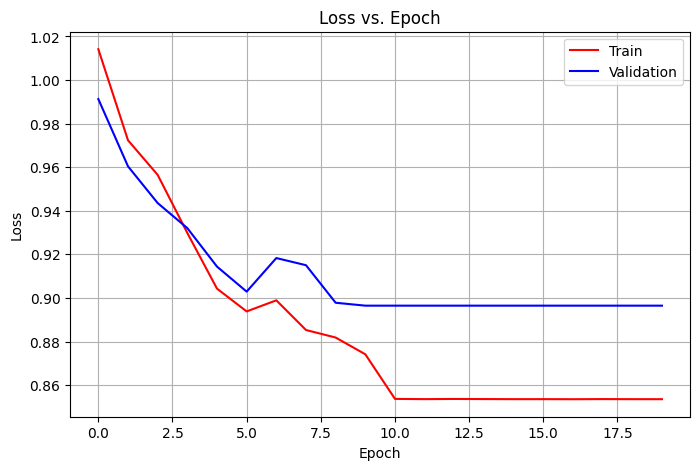

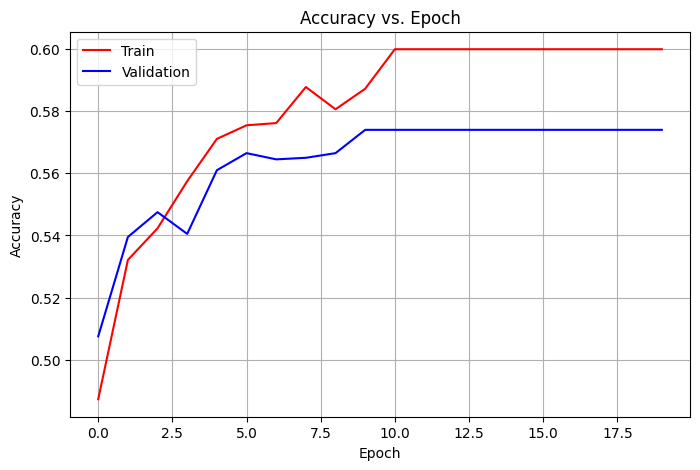

In [37]:
plt.figure(figsize=(8, 5))
plt.plot(range(epoch_counter), loss_train_hist, "r-", label="Train")
plt.plot(range(epoch_counter), loss_valid_hist, "b-", label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs. Epoch")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(range(epoch_counter), acc_train_hist, "r-", label="Train")
plt.plot(range(epoch_counter), acc_valid_hist, "b-", label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs. Epoch")
plt.legend()
plt.grid(True)
plt.show()

# **Extra: Reload & Evaluate on Test Set**

In [39]:
model = RNNModel(
    RNN=nn.RNN,
    vocab_size=vocab_size,
    input_size=embed_dim,
    hidden_size=hidden_dim,
    num_layers=num_layers,
    bidirectional=bidirectional,
    num_cls=num_classes
)

model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
model = model.to(device)
model.eval()
print(f"Model reloaded from {model_path}")

Model reloaded from /content/drive/MyDrive/model.pt


In [40]:
test_loss, test_acc = validation(model, test_loader, loss_fn)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")

Test Loss     : 1.1089
Test Accuracy : 0.4883
